# Introduction to MLOps: How KV-Caches Make LLM Inference Fast

This notebook is used **together with the slides**. Coloured boxes mark the switching points:

- <b style="color:#2B6CB0">▶ SWITCH FROM SLIDES</b>: start here when the dark “Notebook” slide is shown.
- <b style="color:#B4500E">◀ SWITCH BACK TO SLIDES</b>: stop here and continue with the slides.

| Slides | Notebook part | What we do |
|---|---|---|
| 1–3: intro, learning goals, why this is MLOps | — | — |
| 4 | **Part 1** | Load GPT-2 and look inside |
| 5–6: inside GPT-2, one forward pass | — | — |
| 7 | **Part 2** | Generate one token by hand |
| 8: the naive loop | — | — |
| 9 | **Part 3** | Time the loop without a cache |
| 10–12: key insight, prefill vs. decode, cost | — | — |
| 13 | **Part 4** | Add the KV cache and compare |
| 14–17: memory cost, production, summary | — | — |

We use the example prompt **"Machine learning can"** throughout.

*Before the lecture:* run the whole notebook once, so GPT-2 is downloaded and cached. Then uncomment the `HF_HUB_OFFLINE` line in the first code cell, so the demo does not depend on the room's Wi-Fi. Zoom the notebook to about 150% for the audience.

---
<div style="background:#15202B; color:#EEF1F4; padding:14px 20px; border-left:8px solid #7FB2F0; border-radius:6px">
<b style="color:#7FB2F0">▶ SWITCH FROM SLIDES — Notebook Part 1 of 4</b> &nbsp;(slide 4)<br>
<span style="font-size:1.3em"><b>Load GPT-2 and look inside</b></span>
</div>

> **Predict first:** in the printed model, find `c_attn: Conv1D(nf=2304, nx=768)`. Why 2304, when the hidden size is 768?

### Import required packages

In [1]:
import os
# os.environ["HF_HUB_OFFLINE"] = "1"   # lecture day: use the cached model, no network needed
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

### Load the LLM from Hugging Face
We use GPT-2 small (124M parameters). The `HF_TOKEN` warning only means we download anonymously; it is harmless.

In [2]:
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval()  # inference mode: disables dropout

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

### Examine the model's architecture

In [3]:
print(model)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


<details><summary><b>Answer: why 2304?</b> (click to reveal)</summary>

2304 = 3 × 768. One matrix multiplication (`c_attn`) produces the **query, key and value** vectors for every token at once.
The keys and values are exactly what we will cache later. 768 is the hidden size *d*: the length of each token's vector.
</details>

<div style="background:#F6F4EE; color:#1B2430; padding:14px 20px; border-left:8px solid #E07A2E; border-radius:6px">
<b style="color:#B4500E">◀ SWITCH BACK TO SLIDES</b> &nbsp;→ slides 5–6: “Inside GPT-2, with real tensor shapes” and “One forward pass gives one new token”<br>
What these layers compute, and the tensor shapes of one generation step.
</div>

---

---
<div style="background:#15202B; color:#EEF1F4; padding:14px 20px; border-left:8px solid #7FB2F0; border-radius:6px">
<b style="color:#7FB2F0">▶ SWITCH FROM SLIDES — Notebook Part 2 of 4</b> &nbsp;(slide 7)<br>
<span style="font-size:1.3em"><b>Generate one token by hand</b></span>
</div>

> **Predict first:** What will `logits.shape` print? Which word do you expect after “Machine learning can”?

### Tokenize the prompt

In [4]:
prompt = "Machine learning can"
inputs = tokenizer(prompt, return_tensors="pt")
inputs

{'input_ids': tensor([[37573,  4673,   460]]), 'attention_mask': tensor([[1, 1, 1]])}

- See how the prompt was split into tokens (one ID per token). Note the leading spaces.

In [5]:
[tokenizer.decode(t) for t in inputs["input_ids"][0]]

['Machine', ' learning', ' can']

### Run one forward pass and inspect the logits

In [6]:
with torch.no_grad():   # inference only: no gradients needed
    outputs = model(**inputs)

logits = outputs.logits
print(logits.shape)     # [batch, sequence length, vocabulary size]

torch.Size([1, 3, 50257])


- Only the **last position** matters for the next token. Greedy decoding takes the highest score.

In [7]:
last_logits = logits[0, -1, :]
next_token_id = last_logits.argmax()
next_token_id

tensor(307)

In [8]:
tokenizer.decode(next_token_id)

' be'

- The 10 most likely next tokens

In [9]:
top_k = torch.topk(last_logits, k=10)
[tokenizer.decode(tk) for tk in top_k.indices]

[' be',
 ' help',
 ' also',
 ' now',
 ' take',
 "'t",
 ' make',
 ' do',
 ' provide',
 ' improve']

### Append the new token to build the next input
The **whole** sequence (now 4 tokens) goes back into the model for the next step.

In [10]:
next_inputs = {
    "input_ids": torch.cat(
        [inputs["input_ids"], next_token_id.reshape((1, 1))],
        dim=1
    ),
    "attention_mask": torch.cat(
        [inputs["attention_mask"], torch.tensor([[1]])],
        dim=1
    ),
}
print(next_inputs["input_ids"], next_inputs["input_ids"].shape)
print(next_inputs["attention_mask"], next_inputs["attention_mask"].shape)

tensor([[37573,  4673,   460,   307]]) torch.Size([1, 4])
tensor([[1, 1, 1, 1]]) torch.Size([1, 4])


<div style="background:#F6F4EE; color:#1B2430; padding:14px 20px; border-left:8px solid #E07A2E; border-radius:6px">
<b style="color:#B4500E">◀ SWITCH BACK TO SLIDES</b> &nbsp;→ slide 8: “The naive loop recomputes the past every step”<br>
Discuss the repeated work before we measure it.
</div>

---

---
<div style="background:#15202B; color:#EEF1F4; padding:14px 20px; border-left:8px solid #7FB2F0; border-radius:6px">
<b style="color:#7FB2F0">▶ SWITCH FROM SLIDES — Notebook Part 3 of 4</b> &nbsp;(slide 9)<br>
<span style="font-size:1.3em"><b>Time the loop without a cache</b></span>
</div>

> **Predict first:** sketch the time-per-token curve before running it. Flat or rising? Why?

### Text generation helper function
One call = one forward pass over **all** tokens so far = one new token.

In [11]:
def generate_token(inputs):
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    last_logits = logits[0, -1, :]
    next_token_id = last_logits.argmax()
    return next_token_id

- Warm-up: the very first call to a PyTorch model is often slower. We run one untimed call so it does not distort the plot.
- `N_NEW_TOKENS` sets how many tokens both loops generate (default 50). Use 100 if the curve is still noisy.

In [12]:
N_NEW_TOKENS = 50

_ = generate_token(inputs)  # warm-up, not timed

### Generate tokens in a loop, timing each step

In [13]:
generated_tokens = []
next_inputs = inputs
durations_s = []
for _ in range(N_NEW_TOKENS):
    t0 = time.perf_counter()
    next_token_id = generate_token(next_inputs)
    durations_s += [time.perf_counter() - t0]

    next_inputs = {
        "input_ids": torch.cat(
            [next_inputs["input_ids"], next_token_id.reshape((1, 1))],
            dim=1),
        "attention_mask": torch.cat(
            [next_inputs["attention_mask"], torch.tensor([[1]])],
            dim=1),
    }

    generated_tokens.append(tokenizer.decode(next_token_id))

generated_tokens_no_cache = list(generated_tokens)  # keep for comparison in Part 4
print(f"{sum(durations_s):.3f} s")
print(prompt + "".join(generated_tokens))

7.249 s
Machine learning can be used to predict the future.

The first step is to understand the neural network that is responsible for the prediction. The neural network is a set of neurons that are connected to a network of neurons. The network is connected to a network of


### Plot time per token

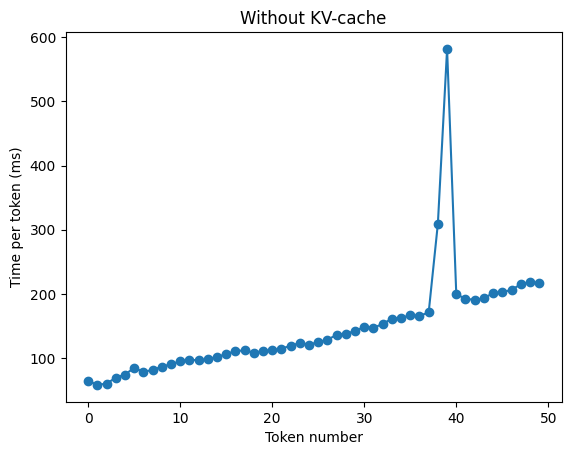

In [14]:
plt.plot(np.array(durations_s) * 1000, marker="o")
plt.xlabel("Token number")
plt.ylabel("Time per token (ms)")
plt.title("Without KV-cache")
plt.show()

<div style="background:#F6F4EE; color:#1B2430; padding:14px 20px; border-left:8px solid #E07A2E; border-radius:6px">
<b style="color:#B4500E">◀ SWITCH BACK TO SLIDES</b> &nbsp;→ slides 10–12: key insight, prefill vs. decode, cost<br>
Why past keys and values never change, and what caching them saves.
</div>

---

---
<div style="background:#15202B; color:#EEF1F4; padding:14px 20px; border-left:8px solid #7FB2F0; border-radius:6px">
<b style="color:#7FB2F0">▶ SWITCH FROM SLIDES — Notebook Part 4 of 4</b> &nbsp;(slide 13)<br>
<span style="font-size:1.3em"><b>Add the KV cache: three lines change</b></span>
</div>

> **Predict first:** Will step 1 with the cache be faster? Why must `attention_mask` keep growing?

### Return the cache from the helper
`outputs.past_key_values` holds one K and one V tensor per layer.
(In recent `transformers` versions this is a `DynamicCache` object instead of a tuple of tensors; the idea is the same.)

In [15]:
def generate_token_with_past(inputs):
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    last_logits = logits[0, -1, :]
    next_token_id = last_logits.argmax()
    return next_token_id, outputs.past_key_values

### Generate with the cache
- **Step 1 = prefill:** the whole prompt goes in and the cache is built.
- **Steps 2+ = decode:** only the newest token goes in (`input_ids` has shape `[1, 1]`), together with the cache.

In [16]:
generated_tokens = []
next_inputs = inputs
durations_cached_s = []
for _ in range(N_NEW_TOKENS):
    t0 = time.perf_counter()
    next_token_id, past_key_values = generate_token_with_past(next_inputs)
    durations_cached_s += [time.perf_counter() - t0]

    next_inputs = {
        "input_ids": next_token_id.reshape((1, 1)),          # only the new token
        "attention_mask": torch.cat(                         # still the full length
            [next_inputs["attention_mask"], torch.tensor([[1]])],
            dim=1),
        "past_key_values": past_key_values,                  # the cache
    }

    generated_tokens.append(tokenizer.decode(next_token_id))

print(f"{sum(durations_cached_s):.3f} s")
print(prompt + "".join(generated_tokens))

2.523 s
Machine learning can be used to predict the future.

The first step is to understand the neural network that is responsible for the prediction. The neural network is a set of neurons that are connected to a network of neurons. The network is connected to a network of


- The cache changes the **speed**, not the **result**:

In [17]:
print("Same text as without the cache:", generated_tokens == generated_tokens_no_cache)

Same text as without the cache: True


### Compare time per token

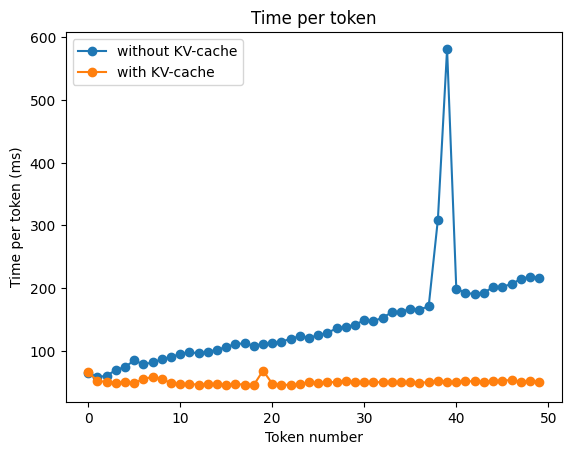

In [18]:
plt.plot(np.array(durations_s) * 1000, marker="o", label="without KV-cache")
plt.plot(np.array(durations_cached_s) * 1000, marker="o", label="with KV-cache")
plt.xlabel("Token number")
plt.ylabel("Time per token (ms)")
plt.legend()
plt.title("Time per token")
plt.savefig("kv_cache_comparison.png", dpi=200, bbox_inches="tight")  # for the backup slide
plt.show()

### Results summary: the serving metrics from slide 3
- **TTFT** (time to first token) = step 1, the prefill.
- **TPOT** (time per output token) = the average of all later steps, the decode.

In [19]:
def ttft_tpot(durations):
    return durations[0] * 1000, np.mean(durations[1:]) * 1000

ttft_nc, tpot_nc = ttft_tpot(durations_s)
ttft_c, tpot_c = ttft_tpot(durations_cached_s)

print(f"Prompt tokens: {inputs['input_ids'].shape[1]}   generated tokens: {N_NEW_TOKENS}")
print(f"{'':22s}{'without cache':>15s}{'with cache':>12s}")
print(f"{'TTFT (ms)':22s}{ttft_nc:15.1f}{ttft_c:12.1f}")
print(f"{'TPOT (ms)':22s}{tpot_nc:15.1f}{tpot_c:12.1f}")
print(f"{'Total time (s)':22s}{sum(durations_s):15.3f}{sum(durations_cached_s):12.3f}")
print(f"Time saved in total: {100 * (1 - sum(durations_cached_s) / sum(durations_s)):.0f} %")

Prompt tokens: 3   generated tokens: 50
                        without cache  with cache
TTFT (ms)                        64.6        65.5
TPOT (ms)                       146.6        50.2
Total time (s)                  7.249       2.523
Time saved in total: 65 %


### Optional: the library does this for you
`model.generate()` uses the KV cache by default (`use_cache=True`). With greedy decoding it should give the same text as our hand-written loop.

In [20]:
with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=N_NEW_TOKENS, do_sample=False,
                         pad_token_id=tokenizer.eos_token_id)
print(tokenizer.decode(out[0]))

Machine learning can be used to predict the future.

The first step is to understand the neural network that is responsible for the prediction. The neural network is a set of neurons that are connected to a network of neurons. The network is connected to a network of


<div style="background:#F6F4EE; color:#1B2430; padding:14px 20px; border-left:8px solid #E07A2E; border-radius:6px">
<b style="color:#B4500E">◀ SWITCH BACK TO SLIDES</b> &nbsp;→ slide 14: “The cache trades compute for memory”<br>
How big the cache gets, and how production systems manage it.
</div>

---

## Take-home experiment
1. Set `N_NEW_TOKENS = 200` and re-run Parts 3 and 4. How do the two curves change?
2. If you have a GPU, move the model and inputs to it (`model.to("cuda")`, `inputs = inputs.to("cuda")`) and compare.
3. Compute the size of the cache: for GPT-2 small in float32 it is 2 × 12 layers × 768 × 4 bytes per token. Check it against `past_key_values`.